# Drug Response and CRISPR Correlation Exploration

This notebook explores drug response data (AUC/IC50) correlated with CRISPR gene knockout Chronos scores.

This data provides evidence for drug-target associations by showing:
- **AUC correlation**: Area Under Curve correlation between drug response and gene knockout
- **IC50 correlation**: Half-maximal inhibitory concentration correlation
- **Chronos scores**: CRISPR gene knockout dependency scores
- **Statistical significance**: P-values, FDR, Bonferroni corrections

Data sources:
- **PRISM**: Broad Institute's PRISM dataset
- **GDSC**: Genomics of Drug Sensitivity in Cancer

## 1. Import Libraries and Load Data

In [1]:
import sys
sys.path.insert(0, '..')
import os
os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load drug response data
drug_response_file = Path("DrugResponse/drug_response_crispr_correlation.csv")
print(f"Loading drug response data from {drug_response_file}...")
drug_response_df = pd.read_csv(drug_response_file, low_memory=False)
print(f"Loaded {len(drug_response_df):,} records")
print(f"Columns: {len(drug_response_df.columns)}")
print(f"\nColumn names:")
print(list(drug_response_df.columns))

Loading drug response data from DrugResponse/drug_response_crispr_correlation.csv...
Loaded 464,820 records
Columns: 23

Column names:
['drugs', 'genes', 'n_shared_celllines', 'AUC_corr', 'AUC_pvalue', 'AUC_FDR', 'AUC_Bonferroni', 'AUC_FDR_sig', 'IC50_corr', 'IC50_pvalue', 'IC50_FDR', 'IC50_Bonferroni', 'IC50_FDR_sig', 'source', 'ChEMBL_ID', 'ChEMBL_ID_prism', 'ChEMBL_ID_ctd', 'drugId', 'phase', 'status', 'Gene', 'mechanismOfAction', 'Status']


## 2. Data Overview

In [3]:
print("=" * 80)
print("DRUG RESPONSE DATA OVERVIEW")
print("=" * 80)
print(f"\nShape: {drug_response_df.shape}")
print(f"\nFirst few rows:")
display(drug_response_df.head(10))

DRUG RESPONSE DATA OVERVIEW

Shape: (464820, 23)

First few rows:


,drugs,genes,n_shared_celllines,AUC_corr,AUC_pvalue,AUC_FDR,AUC_Bonferroni,AUC_FDR_sig,IC50_corr,IC50_pvalue,...,source,ChEMBL_ID,ChEMBL_ID_prism,ChEMBL_ID_ctd,drugId,phase,status,Gene,mechanismOfAction,Status
0,Erlotinib,ABCA4,551,0.185446,3.769011e-07,0.000139,1.0,True,0.063110,0.086240,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Erlotinib,ABCA7,551,-0.137829,1.692567e-04,0.013885,1.0,True,-0.115983,0.001575,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Erlotinib,ABCC4,551,-0.137237,1.806260e-04,0.014516,1.0,True,-0.044414,0.227534,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Erlotinib,ACAD8,551,-0.080038,2.947444e-02,0.296847,1.0,False,-0.112729,0.002132,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Erlotinib,ACAT1,551,-0.193713,1.090079e-07,0.000052,1.0,True,-0.172645,0.000002,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Erlotinib,ACLY,551,-0.120824,9.902019e-04,0.045147,1.0,True,0.050220,0.172351,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Erlotinib,ACOXL,551,0.132849,2.902457e-04,0.020120,1.0,True,0.060729,0.098790,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Erlotinib,ACP1,551,-0.169823,3.389906e-06,0.000781,1.0,True,-0.126703,0.000551,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Erlotinib,ACP3,551,-0.149339,4.532793e-05,0.005454,1.0,True,-0.101536,0.005700,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Erlotinib,ACTB,551,0.129594,4.088849e-04,0.025310,1.0,True,0.077197,0.035766,...,GDSC,CHEMBL553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("=" * 80)
print("DATA STATISTICS")
print("=" * 80)

print(f"\nUnique drugs: {drug_response_df['drugs'].nunique() if 'drugs' in drug_response_df.columns else 'N/A'}")
print(f"Unique genes: {drug_response_df['genes'].nunique() if 'genes' in drug_response_df.columns else 'N/A'}")
print(f"Unique ChEMBL IDs: {drug_response_df['ChEMBL_ID'].nunique() if 'ChEMBL_ID' in drug_response_df.columns else 'N/A'}")

if 'source' in drug_response_df.columns:
    print(f"\nData sources:")
    print(drug_response_df['source'].value_counts())

# Correlation statistics
if 'AUC_corr' in drug_response_df.columns:
    print(f"\nAUC Correlation statistics:")
    print(drug_response_df['AUC_corr'].describe())

if 'IC50_corr' in drug_response_df.columns:
    print(f"\nIC50 Correlation statistics:")
    print(drug_response_df['IC50_corr'].describe())

DATA STATISTICS

Unique drugs: 1109
Unique genes: 17029
Unique ChEMBL IDs: 899

Data sources:
source
GDSC         324720
PRISM_CTD    137358
PRISM          2742
Name: count, dtype: int64

AUC Correlation statistics:
count    464820.000000
mean          0.039864
std           0.142491
min          -0.807577
25%          -0.101902
50%           0.084640
75%           0.151749
max           0.966172
Name: AUC_corr, dtype: float64

IC50 Correlation statistics:
count    324720.000000
mean          0.050017
std           0.146366
min          -0.554581
25%          -0.111073
50%           0.114660
75%           0.158353
max           0.641094
Name: IC50_corr, dtype: float64


## 3. Significant Associations

Find drug-target associations with significant correlations (FDR < 0.05)

In [5]:
# Significant AUC correlations
if 'AUC_FDR_sig' in drug_response_df.columns:
    sig_auc = drug_response_df[drug_response_df['AUC_FDR_sig'] == True].copy()
    print(f"Significant AUC correlations (FDR < 0.05): {len(sig_auc):,}")
    
    print(f"\nTop 20 strongest positive AUC correlations:")
    top_positive = sig_auc.nlargest(20, 'AUC_corr')
    display_cols = ['drugs', 'genes', 'ChEMBL_ID', 'AUC_corr', 'AUC_pvalue', 'AUC_FDR', 'source', 'n_shared_celllines']
    available = [col for col in display_cols if col in top_positive.columns]
    display(top_positive[available])
    
    print(f"\nTop 20 strongest negative AUC correlations:")
    top_negative = sig_auc.nsmallest(20, 'AUC_corr')
    display(top_negative[available])

Significant AUC correlations (FDR < 0.05): 289,818

Top 20 strongest positive AUC correlations:


,drugs,genes,ChEMBL_ID,AUC_corr,AUC_pvalue,AUC_FDR,source,n_shared_celllines
327435,FELBAMATE (BRD:BRD-K99107520-001-24-1),FNIP2,CHEMBL1094,0.966172,1.342664e-06,2.432909e-02,PRISM,11
327040,CARBACHOL (BRD:BRD-K75037734-003-13-9),GFI1,CHEMBL965,0.888105,4.360152e-06,4.669641e-02,PRISM,16
325303,GW-501516 (BRD:BRD-K14880289-001-02-2),LOX,CHEMBL38943,0.849122,4.269870e-06,4.621660e-02,PRISM,19
327229,ALMOREXANT (BRD:BRD-K84810405-003-01-1),PAQR8,CHEMBL455136,0.828574,1.909612e-06,2.961325e-02,PRISM,22
327250,SOBETIROME (BRD:BRD-K85406984-001-01-0),ZWILCH,CHEMBL107400,0.796764,3.176686e-06,3.969272e-02,PRISM,24
326181,ENZALUTAMIDE (BRD:BRD-K56851771-001-06-8),WDR75,CHEMBL1082407,0.784182,2.134384e-06,3.168816e-02,PRISM,26
324739,SCLAREOL (BRD:BRD-A23127772-001-02-3),RNF212B,CHEMBL294740,0.774864,2.086306e-06,3.114851e-02,PRISM,27
326502,AMG-232 (BRD:BRD-K64925568-001-01-8),MDM2,CHEMBL3125702,0.764820,6.731646e-39,1.643037e-31,PRISM,196
326503,AMG-232 (BRD:BRD-K64925568-001-01-8),MDM2,CHEMBL3125702,0.764820,6.731646e-39,1.643037e-31,PRISM,196
326504,AMG-232 (BRD:BRD-K64925568-001-01-8),MDM2,CHEMBL3125702,0.764820,6.731646e-39,1.643037e-31,PRISM,196



Top 20 strongest negative AUC correlations:


,drugs,genes,ChEMBL_ID,AUC_corr,AUC_pvalue,AUC_FDR,source,n_shared_celllines
325767,BUMETANIDE (BRD:BRD-K38197229-001-29-9),LAMA4,CHEMBL1072,-0.807577,1.061441e-06,2.096060e-02,PRISM,25
325364,CREATINE (BRD:BRD-K19615002-001-02-3),HPS6,CHEMBL283800,-0.773221,2.262705e-06,3.291260e-02,PRISM,27
326348,IDASANUTLIN (BRD:BRD-K62627508-001-01-5),TP53,CHEMBL2402737,-0.731188,1.040079e-29,6.346477e-23,PRISM,170
326349,IDASANUTLIN (BRD:BRD-K62627508-001-01-5),TP53,CHEMBL2402737,-0.731188,1.040079e-29,6.346477e-23,PRISM,170
326350,IDASANUTLIN (BRD:BRD-K62627508-001-01-5),TP53,CHEMBL2402737,-0.731188,1.040079e-29,6.346477e-23,PRISM,170
326351,IDASANUTLIN (BRD:BRD-K62627508-001-01-5),TP53,CHEMBL2402737,-0.731188,1.040079e-29,6.346477e-23,PRISM,170
326352,IDASANUTLIN (BRD:BRD-K62627508-001-01-5),TP53,CHEMBL2402737,-0.731188,1.040079e-29,6.346477e-23,PRISM,170
326353,IDASANUTLIN (BRD:BRD-K62627508-001-01-5),TP53,CHEMBL2402737,-0.731188,1.040079e-29,6.346477e-23,PRISM,170
326532,AMG-232 (BRD:BRD-K64925568-001-01-8),TP53,CHEMBL3125702,-0.725886,2.312672e-33,1.881564e-26,PRISM,196
326533,AMG-232 (BRD:BRD-K64925568-001-01-8),TP53,CHEMBL3125702,-0.725886,2.312672e-33,1.881564e-26,PRISM,196


In [6]:
# Significant IC50 correlations
if 'IC50_FDR_sig' in drug_response_df.columns:
    sig_ic50 = drug_response_df[drug_response_df['IC50_FDR_sig'] == True].copy()
    print(f"Significant IC50 correlations (FDR < 0.05): {len(sig_ic50):,}")
    
    print(f"\nTop 20 strongest positive IC50 correlations:")
    top_positive = sig_ic50.nlargest(20, 'IC50_corr')
    display_cols = ['drugs', 'genes', 'ChEMBL_ID', 'IC50_corr', 'IC50_pvalue', 'IC50_FDR', 'source', 'n_shared_celllines']
    available = [col for col in display_cols if col in top_positive.columns]
    display(top_positive[available])
    
    print(f"\nTop 20 strongest negative IC50 correlations:")
    top_negative = sig_ic50.nsmallest(20, 'IC50_corr')
    display(top_negative[available])

Significant IC50 correlations (FDR < 0.05): 295,831

Top 20 strongest positive IC50 correlations:


,drugs,genes,ChEMBL_ID,IC50_corr,IC50_pvalue,IC50_FDR,source,n_shared_celllines
271621,AZD5991,MCL1,CHEMBL3353410,0.641094,5.942386e-52,4.136878e-46,GDSC,436
6036,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6037,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6038,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6039,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6040,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6041,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6042,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6043,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200
6044,Imatinib,BCR,CHEMBL941,0.609931,9.142820e-22,2.173383e-17,GDSC,200



Top 20 strongest negative IC50 correlations:


,drugs,genes,ChEMBL_ID,IC50_corr,IC50_pvalue,IC50_FDR,source,n_shared_celllines
197529,XMD11-50,NRF1,CHEMBL2012582,-0.554581,5.173087e-06,5.398529e-04,GDSC,59
203073,torin2,FDPS,CHEMBL1765602,-0.540185,3.318040e-07,6.060461e-05,GDSC,78
197555,XMD11-50,SNRPF,CHEMBL2012582,-0.533968,1.328425e-05,1.128868e-03,GDSC,59
197531,XMD11-50,PAIP2B,CHEMBL2012582,-0.513396,3.207646e-05,2.226815e-03,GDSC,59
197534,XMD11-50,PHF5A,CHEMBL2012582,-0.483926,1.031308e-04,5.392635e-03,GDSC,59
197578,XMD11-50,ZC3H12C,CHEMBL2012582,-0.479223,1.230610e-04,6.154569e-03,GDSC,59
197545,XMD11-50,SATB2,CHEMBL2012582,-0.479064,1.237914e-04,6.181741e-03,GDSC,59
197577,XMD11-50,ZBTB7B,CHEMBL2012582,-0.471341,1.645392e-04,7.633296e-03,GDSC,59
197554,XMD11-50,SLCO5A1,CHEMBL2012582,-0.471000,1.665912e-04,7.702720e-03,GDSC,59
197486,XMD11-50,C10orf71,CHEMBL2012582,-0.470744,1.681478e-04,7.756516e-03,GDSC,59


## 4. Drug-Target Association Evidence

This data provides evidence for drug-target associations:
- **Positive correlation**: Gene knockout increases drug sensitivity (gene may be resistance factor)
- **Negative correlation**: Gene knockout decreases drug sensitivity (gene may be target or required for drug action)

In [7]:
# Example: Find associations for a specific drug
example_drug = "Erlotinib"
print(f"=" * 80)
print(f"DRUG-TARGET ASSOCIATIONS FOR {example_drug}")
print("=" * 80)

drug_associations = drug_response_df[drug_response_df['drugs'] == example_drug].copy()

if not drug_associations.empty:
    print(f"\nFound {len(drug_associations)} gene associations")
    
    # Significant associations
    sig_associations = drug_associations[
        (drug_associations.get('AUC_FDR_sig', pd.Series([False] * len(drug_associations))) == True) |
        (drug_associations.get('IC50_FDR_sig', pd.Series([False] * len(drug_associations))) == True)
    ]
    
    print(f"Significant associations: {len(sig_associations)}")
    
    if not sig_associations.empty:
        display_cols = ['genes', 'AUC_corr', 'AUC_FDR_sig', 'IC50_corr', 'IC50_FDR_sig', 
                       'n_shared_celllines', 'source', 'ChEMBL_ID']
        available = [col for col in display_cols if col in sig_associations.columns]
        display(sig_associations[available].head(20))
else:
    print(f"No associations found for {example_drug}")

DRUG-TARGET ASSOCIATIONS FOR Erlotinib

Found 963 gene associations
Significant associations: 963


,genes,AUC_corr,AUC_FDR_sig,IC50_corr,IC50_FDR_sig,n_shared_celllines,source,ChEMBL_ID
0,ABCA4,0.185446,True,0.063110,False,551,GDSC,CHEMBL553
1,ABCA7,-0.137829,True,-0.115983,True,551,GDSC,CHEMBL553
2,ABCC4,-0.137237,True,-0.044414,False,551,GDSC,CHEMBL553
3,ACAD8,-0.080038,False,-0.112729,True,551,GDSC,CHEMBL553
4,ACAT1,-0.193713,True,-0.172645,True,551,GDSC,CHEMBL553
5,ACLY,-0.120824,True,0.050220,False,551,GDSC,CHEMBL553
6,ACOXL,0.132849,True,0.060729,False,551,GDSC,CHEMBL553
7,ACP1,-0.169823,True,-0.126703,True,551,GDSC,CHEMBL553
8,ACP3,-0.149339,True,-0.101536,False,551,GDSC,CHEMBL553
9,ACTB,0.129594,True,0.077197,False,551,GDSC,CHEMBL553


In [8]:
# Example: Find associations for a specific gene
example_gene = "EGFR"
print(f"=" * 80)
print(f"DRUG ASSOCIATIONS FOR GENE {example_gene}")
print("=" * 80)

gene_associations = drug_response_df[drug_response_df['genes'] == example_gene].copy()

if not gene_associations.empty:
    print(f"\nFound {len(gene_associations)} drug associations")
    
    # Significant associations
    sig_associations = gene_associations[
        (gene_associations.get('AUC_FDR_sig', pd.Series([False] * len(gene_associations))) == True) |
        (gene_associations.get('IC50_FDR_sig', pd.Series([False] * len(gene_associations))) == True)
    ]
    
    print(f"Significant associations: {len(sig_associations)}")
    
    if not sig_associations.empty:
        display_cols = ['drugs', 'AUC_corr', 'AUC_FDR_sig', 'IC50_corr', 'IC50_FDR_sig', 
                       'n_shared_celllines', 'source', 'ChEMBL_ID']
        available = [col for col in display_cols if col in sig_associations.columns]
        display(sig_associations[available].head(20))
else:
    print(f"No associations found for {example_gene}")

DRUG ASSOCIATIONS FOR GENE EGFR

Found 620 drug associations
Significant associations: 620


,drugs,AUC_corr,AUC_FDR_sig,IC50_corr,IC50_FDR_sig,n_shared_celllines,source,ChEMBL_ID
240,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
241,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
242,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
243,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
244,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
245,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
246,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
247,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
248,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
249,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553


## 5. Visualization

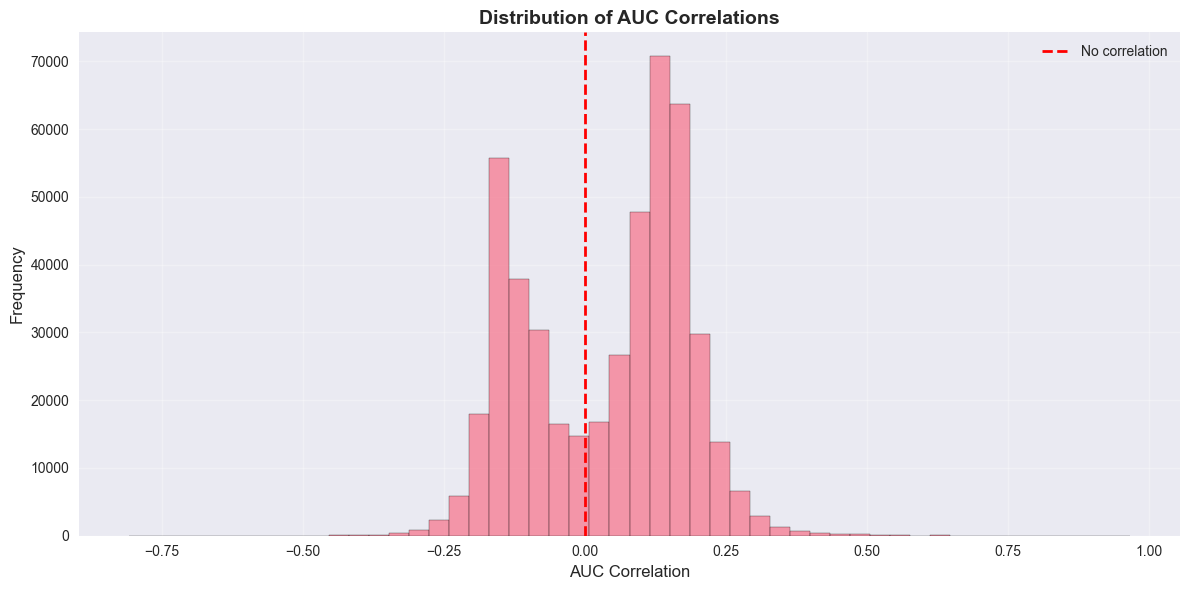

In [9]:
# Distribution of AUC correlations
if 'AUC_corr' in drug_response_df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(drug_response_df['AUC_corr'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No correlation')
    plt.xlabel('AUC Correlation', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of AUC Correlations', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

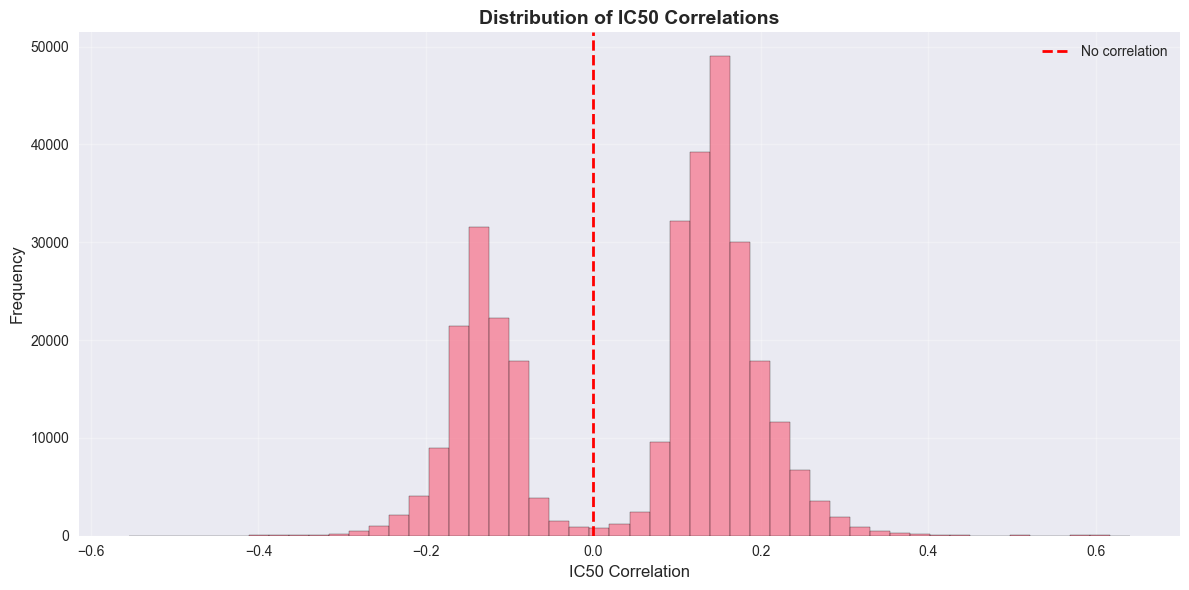

In [10]:
# Distribution of IC50 correlations
if 'IC50_corr' in drug_response_df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(drug_response_df['IC50_corr'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No correlation')
    plt.xlabel('IC50 Correlation', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of IC50 Correlations', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [11]:
# Create drug name to ChEMBL ID mapping
def get_drug_id_mapping(df, drug_col='drugs', chembl_col='ChEMBL_ID'):
    """Create mapping from drug name to ChEMBL ID."""
    if drug_col in df.columns and chembl_col in df.columns:
        mapping = df[[drug_col, chembl_col]].drop_duplicates()
        mapping = mapping[mapping[chembl_col].notna()]
        return dict(zip(mapping[drug_col], mapping[chembl_col]))
    return {}

# Create ChEMBL ID to drug name mapping
def get_drug_name_mapping(df, drug_col='drugs', chembl_col='ChEMBL_ID'):
    """Create mapping from ChEMBL ID to drug name."""
    if drug_col in df.columns and chembl_col in df.columns:
        mapping = df[[drug_col, chembl_col]].drop_duplicates()
        mapping = mapping[mapping[chembl_col].notna()]
        return dict(zip(mapping[chembl_col], mapping[drug_col]))
    return {}

# Create gene to drug associations mapping
def get_gene_drug_mapping(df, gene_col='genes', drug_col='drugs'):
    """Create mapping from gene to list of associated drugs."""
    if gene_col in df.columns and drug_col in df.columns:
        return df.groupby(gene_col)[drug_col].apply(list).to_dict()
    return {}

# Create mappings
drug_to_chembl = get_drug_id_mapping(drug_response_df)
chembl_to_drug = get_drug_name_mapping(drug_response_df)
gene_to_drugs = get_gene_drug_mapping(drug_response_df)

print(f"Drug to ChEMBL ID mappings: {len(drug_to_chembl):,}")
print(f"ChEMBL ID to drug mappings: {len(chembl_to_drug):,}")
print(f"Gene to drugs mappings: {len(gene_to_drugs):,}")

# Example lookups
example_drug = "Erlotinib"
example_chembl = "CHEMBL553"
example_gene = "EGFR"

print(f"\nExample: Drug '{example_drug}' → ChEMBL ID: {drug_to_chembl.get(example_drug, 'Not found')}")
print(f"Example: ChEMBL ID '{example_chembl}' → Drug: {chembl_to_drug.get(example_chembl, 'Not found')}")
print(f"Example: Gene '{example_gene}' → Associated drugs: {len(gene_to_drugs.get(example_gene, []))} drugs")

Drug to ChEMBL ID mappings: 1,109
ChEMBL ID to drug mappings: 899
Gene to drugs mappings: 17,029

Example: Drug 'Erlotinib' → ChEMBL ID: CHEMBL553
Example: ChEMBL ID 'CHEMBL553' → Drug: ERLOTINIB (CTRP:52928)
Example: Gene 'EGFR' → Associated drugs: 620 drugs


## 7. Summary and Next Steps

This exploration shows:
- Drug response data provides evidence for drug-target associations through CRISPR correlation
- Significant correlations (FDR < 0.05) indicate strong associations
- Positive correlations suggest resistance mechanisms
- Negative correlations suggest target or required pathways
- Data includes both PRISM and GDSC sources

Next: Integrate this data into the main database query system.